In [50]:
#Part 2 ile başla. Önceki üç harfi bağlam alan veri setini kur (X: 3 harf indeksi, Y: sıradaki harf). Embedding tablosunu (27x2) oluştur, indeksleme ile embedding'leri çek. (Part 2, 9:03 - 18:35)

In [183]:
#chs = ['.', '.', '.', 'a', 'h', 'm', 'e', 't', '.']

#X[...] → Y[a]     
#X[..a] → Y[h]
#X[.ah] → Y[m]
#X[ahm] → Y[e]    
#X[hme] → Y[t]     
#X[met] → Y[.]    

In [3]:
import torch
import torch.nn. functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [4]:
words = open('turkce_isimler.txt','r').read().splitlines()
words[:10]

['Ada',
 'Adaadem',
 'Adaahmet',
 'Adaali',
 'Adaalp',
 'Adaalparslan',
 'Adaalper',
 'Adaarda',
 'Adaasel',
 'Adaaslan']

In [5]:
def lowercase(s):
    s = s.replace('İ', 'i').replace('I', 'ı')
    return s.lower()

words_cleaned = [lowercase(n) for n in words]
print(words_cleaned[:10])
words = words_cleaned.copy()

['ada', 'adaadem', 'adaahmet', 'adaali', 'adaalp', 'adaalparslan', 'adaalper', 'adaarda', 'adaasel', 'adaaslan']


In [6]:
len(words)

103637

In [7]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)} 
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'y': 22, 'z': 23, 'ç': 24, 'ö': 25, 'ü': 26, 'ğ': 27, 'ı': 28, 'ş': 29, '.': 0}


In [8]:
def building_dataset(data):
    block_size = 3 # input sayısı
    X, Y = [], []

    for w in data:  # context length: how many characters do we take to predict the next one ?

        #print(w)
        context = [0] * block_size  # [0, 0, 0] X e girecek train datası 
        for ch in w + '.': 
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)

            #print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix] 

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y


In [148]:
X, Y = building_dataset(words[:5])

ada
... ----> a
..a ----> d
.ad ----> a
ada ----> .
adaadem
... ----> a
..a ----> d
.ad ----> a
ada ----> a
daa ----> d
aad ----> e
ade ----> m
dem ----> .
adaahmet
... ----> a
..a ----> d
.ad ----> a
ada ----> a
daa ----> h
aah ----> m
ahm ----> e
hme ----> t
met ----> .
adaali
... ----> a
..a ----> d
.ad ----> a
ada ----> a
daa ----> l
aal ----> i
ali ----> .
adaalp
... ----> a
..a ----> d
.ad ----> a
ada ----> a
daa ----> l
aal ----> p
alp ----> .


In [149]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([35, 3]), torch.int64, torch.Size([35]), torch.int64)

In [150]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1,  4],
        [ 1,  4,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1,  4],
        [ 1,  4,  1],
        [ 4,  1,  1],
        [ 1,  1,  4],
        [ 1,  4,  5],
        [ 4,  5, 13],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1,  4],
        [ 1,  4,  1],
        [ 4,  1,  1],
        [ 1,  1,  8],
        [ 1,  8, 13],
        [ 8, 13,  5],
        [13,  5, 19],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1,  4],
        [ 1,  4,  1],
        [ 4,  1,  1],
        [ 1,  1, 12],
        [ 1, 12,  9],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1,  4],
        [ 1,  4,  1],
        [ 4,  1,  1],
        [ 1,  1, 12],
        [ 1, 12, 16]])

In [151]:
Y

tensor([ 1,  4,  1,  0,  1,  4,  1,  1,  4,  5, 13,  0,  1,  4,  1,  1,  8, 13,
         5, 19,  0,  1,  4,  1,  1, 12,  9,  0,  1,  4,  1,  1, 12, 16,  0])

In [152]:
C = torch.randn((30, 2)) 

In [153]:
C[5] #örnek ikisinin aynı olduğunu kanıtlamak için 

tensor([-0.7549, -0.1943])

In [154]:
F.one_hot(torch.tensor(5), num_classes=30).float() @ C #örnek 

tensor([-0.7549, -0.1943])

In [155]:
emb = C[X]
emb.shape

torch.Size([35, 3, 2])

In [ ]:
W1 = torch.randn((6, 100)) 
b1 = torch.randn((100))

In [157]:
h = torch.tanh(emb.view(35, 6) @ W1 + b1)
#h = emb.view(emb.shape[0], 6) @ W1 + b1   shape[0] yerine -1 de konulabilir.

In [158]:
#torch.cat(torch.unbind(emb, 1), 1).shape  bu yol yeni memoryler oluşturduğu için daha az efficient

In [159]:
h.shape

torch.Size([35, 100])

In [160]:
h

tensor([[ 1.0000,  1.0000,  1.0000,  ...,  0.9612,  0.9982,  0.9872],
        [ 0.9999,  0.9979,  0.9579,  ...,  0.9967,  0.9706,  0.5104],
        [-0.0281, -0.1015, -0.8752,  ...,  0.9972, -0.7421, -0.9929],
        ...,
        [-0.9971, -0.9950, -0.9537,  ...,  0.1463,  0.0657, -0.5568],
        [-0.8856, -0.4349, -0.8958,  ...,  0.8293,  0.2981,  0.7734],
        [ 0.6602,  0.3340,  0.9488,  ...,  0.8623,  0.9025,  0.0987]])

In [161]:
# broadcastinge dikkat
print(b1.shape)
(emb.view(35, 6) @ W1).shape

torch.Size([100])


torch.Size([35, 100])

In [162]:
# final layer
W2 = torch.randn((100, 30)) #input değeri 100 h.shape e bak  
b2 = torch.randn((30)) #bias ise 30 zaten 30 tane karakter var 

In [163]:
logits = h @ W2 + b2

In [164]:
logits.shape

torch.Size([35, 30])

In [165]:
counts = logits.exp()

In [166]:
prob = counts / counts.sum(1, keepdim=True)

In [167]:
prob[0].sum() #her satırın toplamı 1 

tensor(1.0000)

In [168]:
prob.shape

torch.Size([35, 30])

In [169]:
prob[torch.arange(35), Y]

tensor([6.0914e-10, 2.3797e-14, 3.7947e-05, 3.0697e-08, 6.0914e-10, 2.3797e-14,
        3.7947e-05, 3.6627e-14, 3.4530e-10, 4.3996e-05, 1.8333e-01, 9.4077e-09,
        6.0914e-10, 2.3797e-14, 3.7947e-05, 3.6627e-14, 1.0080e-06, 4.9523e-11,
        1.2569e-11, 1.2620e-12, 3.6533e-07, 6.0914e-10, 2.3797e-14, 3.7947e-05,
        3.6627e-14, 1.6562e-09, 3.9162e-09, 1.2407e-09, 6.0914e-10, 2.3797e-14,
        3.7947e-05, 3.6627e-14, 1.6562e-09, 2.2902e-09, 1.2235e-05])

In [170]:
loss = -prob[torch.arange(35), Y].log().mean()   #nll 
loss

tensor(20.6643)

In [171]:
#  Summary

In [172]:
# dataset
X.shape, Y.shape

(torch.Size([35, 3]), torch.Size([35]))

In [173]:
g = torch.Generator().manual_seed(42)
C = torch.randn((30, 2), generator=g)
W1 = torch.randn((6, 100))
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 30), generator=g)
b2 = torch.randn(30, generator=g)
parameters = [C, W1, b1, W2, b2]

In [174]:
sum(p.nelement() for p in parameters) # total num of parameters

3790

In [177]:
for p in parameters:
    p.requires_grad = True

In [178]:
for _ in range(10):
    #forward pass
    emb = C[X] # (35, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (35, 100)
    logits = h @ W2 + b2  # (35, 30)
    loss = F.cross_entropy(logits, Y)

    #counts = logits.exp()
    #prob = counts / counts.sum(1, keepdim=True)
    #loss = -prob[torch.arange(35), Y].log().mean()

    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -0.1 * p.grad

14.444087028503418
10.448664665222168
8.069924354553223
6.407386779785156
5.392932891845703
4.6526336669921875
4.1583051681518555
3.828819513320923
3.540130853652954
3.27593994140625


## Görev 1 - Tüm veriseti üzerinde kullanım

In [130]:
#Part 2 ile başla. Önceki üç harfi bağlam alan veri setini kur (X: 3 harf indeksi, Y: sıradaki harf). Embedding tablosunu (27x2) oluştur, indeksleme ile embedding'leri çek. (Part 2, 9:03 - 18:35)

In [190]:
X, Y = building_dataset(words)

In [191]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([1114958, 3]), torch.int64, torch.Size([1114958]), torch.int64)

In [ ]:
C = torch.randn((30, 2)) # türkçe veriseti kullandığım için 27,2 yerine 30,2 kullandım 

In [193]:
#Tek bir index için embedding'e erişim 
F.one_hot(torch.tensor(5), num_classes=30).float() @ C

tensor([-0.5350, -0.4579])

In [194]:
C[5]

tensor([-0.5350, -0.4579])

In [195]:
# Çoklu index ile indeksleme
C[torch.tensor([5,6,7])]

tensor([[-0.5350, -0.4579],
        [ 0.3538, -1.1308],
        [ 0.8234, -1.9608]])

In [196]:
# Tüm X üzerinde indeksleme
emb = C[X]
emb.shape 

torch.Size([1114958, 3, 2])

## Görev 2 

In [197]:
#Gizli katmanı ve çıkış katmanını kur: embedding'leri düzleştir, W1 ve b1 ile tanh, W2 ve b2 ile logits. Loss'u geçen haftaki gibi elle hesapla, sonra F.cross_entropy ile aynı sonucu aldığını göster ve neden onu tercih ettiğimizi videodan anla. (18:35 - 37:56)

In [198]:
# Embeddingleri düzleştirme
emb.view(-1, 6) 

tensor([[ 1.3754,  0.4774,  1.3754,  0.4774,  1.3754,  0.4774],
        [ 1.3754,  0.4774,  1.3754,  0.4774, -0.2481,  1.6079],
        [ 1.3754,  0.4774, -0.2481,  1.6079,  0.7396, -1.0059],
        ...,
        [-0.9012,  1.2495,  0.2804, -1.3080, -0.9013,  0.3446],
        [ 0.2804, -1.3080, -0.9013,  0.3446,  0.3538, -1.1308],
        [-0.9013,  0.3446,  0.3538, -1.1308,  0.2804, -1.3080]])

In [199]:
(emb.view(-1, 6)).shape[0]

1114958

In [200]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 30), generator=g)
b2 = torch.randn(30, generator=g)
parameters = [C, W1, b1, W2, b2]

In [201]:
sum(p.nelement() for p in parameters) 

3790

In [202]:
for p in parameters:
    p.requires_grad = True

In [203]:
#gizli katman
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [204]:
logits = h @ W2 + b2

In [205]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange((emb.view(-1, 6)).shape[0]), Y].log().mean()
loss

tensor(16.9155, grad_fn=<NegBackward0>)

In [206]:
loss = F.cross_entropy(logits, Y)
loss

tensor(16.9155, grad_fn=<NllLossBackward0>)

In [ ]:
# Neden elle loss hesaplamak yerine cross entropy kullanıyoruz?
# Elle hesaplamada exp() çok büyük sayılarla overflow'a uğrayıp nan üretebilir
# F.cross_entropy bunu içeride otomatik düzeltir. Ayrıca tüm adımları tek, optimize bir işlemde yaptığı için hem daha hızlı çalışır hem de gradyan hesaplaması daha kararlıdır.

In [ ]:
for _ in range(2000):
    #forward pass
    emb = C[X] # (1114958, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (1114958, 100)
    logits = h @ W2 + b2  # (1114958, 30)
    loss = F.cross_entropy(logits, Y)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())  # yaklaşık 22 dakika sürdü ve 16.9155 ten 2.56 ya düşürülmesi sağlandı.

2.5627949237823486


In [ ]:
# One-hot yerine embedding kullanıyoruz çünkü one-hot'ta bütün harfler birbirinden eşit uzaklıkta sayılır, aralarında hiçbir benzerlik bilgisi yoktur.
# Embedding ise her harf için öğrenilebilir küçük boyutlu bir vektör oluşturur bu sayede model eğitim sırasında hangi harflerin benzer bağlamlarda kullanıldığını kendisi öğrenir 

## Görev 3 ve Görev 4

In [ ]:
#Eğitim döngüsünü kur: önce tek bir minibatch'i overfit et, sonra bütün veriyi minibatch'lerle eğit. Learning rate'i videodaki gibi tara ve iyi bir değer seç. Veriyi train / dev / test olarak böl, loss'u dev üzerinde raporla. (37:56 - 1:00:49)

In [ ]:
# Gizli katmanı ve embedding boyutunu büyütüp dev loss'un nasıl değiştiğini göster. Embedding'leri 2 boyutta çizdir: hangi harfler birbirine yakın düşüyor? Modelden isimler örnekle, bigram'ınkilerle karşılaştır. (1:00:49 - 1:13:24)

In [230]:
#tüm veri seti. üzerinde yaptığım için parametreleri baştan kuruyoruz
vocab_size = len(stoi)   # 30
block_size = 3
n_embd = 2                # embedding boyutu
n_hidden = 100             # gizli katman nöron sayısı

g = torch.Generator().manual_seed(42)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

3790

In [217]:
X, Y= building_dataset(words[:5])

for _ in range(100): 
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))

    #forward pass

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    


    # backward pass

    for p in parameters:
        p.grad = None
    loss.backward()

    #update

    for p in parameters:
        p.data += -0.1 * p.grad
        
print(loss.item()) 

0.3158205449581146


In [ ]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [252]:
#tüm veri üzerinde minibatch
X, Y= building_dataset(words)
print(X.shape, Y.shape)

lri = []
lossi = []

for i in range(1000): 
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))

    #forward pass

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    


    # backward pass

    for p in parameters:
        p.grad = None
    loss.backward()

    #update

    #lr = lrs[i] 
     
    for p in parameters:
        p.data += -0.25 * p.grad

    #track stats
    #lri.append(lr)
    #lossi.append(loss.item())

        
print(loss.item()) 

torch.Size([1114958, 3]) torch.Size([1114958])
2.391347885131836


In [253]:
emb = C[X]
h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.4515, grad_fn=<NllLossBackward0>)

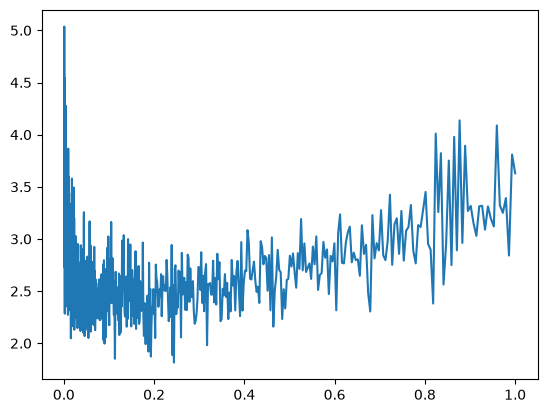

In [251]:
plt.plot(lri, lossi)

In [9]:
# training split, dev/validation split, test split
# %80, %10, %10
X, Y = building_dataset(words)

import random
random.seed(42)
random.shuffle(words)
n1= int(0.8 * len(words))
n2= int(0.9 * len(words))
Xtr, Ytr = building_dataset(words[:n1])
Xdev, Ydev = building_dataset(words[n1:n2])
Xte, Yte = building_dataset(words[n2:])

In [10]:
len(words)

103637

In [11]:
n1

82909

In [12]:
n2

93273

In [13]:
n2 - n1  # dev examples

10364

In [14]:
len(words) - n2  # test examples

10364

In [15]:
Xtr.shape, Ytr.shape

(torch.Size([891788, 3]), torch.Size([891788]))

In [291]:

vocab_size = len(stoi)   # 30
block_size = 3
n_embd = 2                # embedding boyutu
n_hidden = 400             # gizli katman nöron sayısı

g = torch.Generator().manual_seed(42)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

14890

In [309]:
lossi = []
stepi = []

for i in range(30000): 
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    #forward pass

    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    


    # backward pass

    for p in parameters:
        p.grad = None
    loss.backward()

    #update
     
    for p in parameters:
        p.data += -0.1 * p.grad

    #track stats
    stepi.append(i)
    lossi.append(loss.item())

        
print(loss.item()) 

2.289128541946411


In [310]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0581, grad_fn=<NllLossBackward0>)

In [311]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.0712, grad_fn=<NllLossBackward0>)

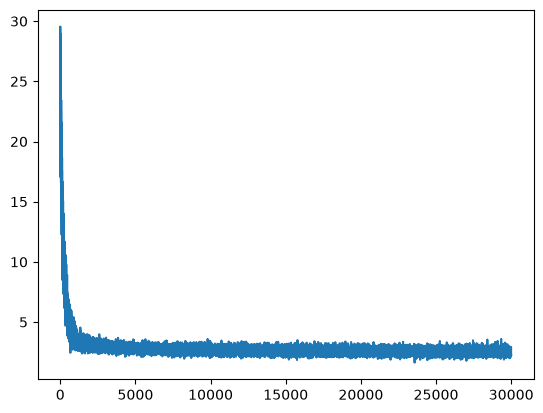

In [272]:
plt.plot(stepi, lossi)

In [ ]:
# 200 hidden layer ile  lr:0.01 ile 30000 adımda loss: 2.0912  - dev 
# 300 hidden layer ile lr:0.01 ile 30000 adımda loss: 2.3918 - dev 
# 400 hidden layer ile lr:0.01 ile 30000 adımda loss: 2.6000 ilk çalıştırmada en sonki çalıştırmada lr:0.1 ve loss: 2.0712

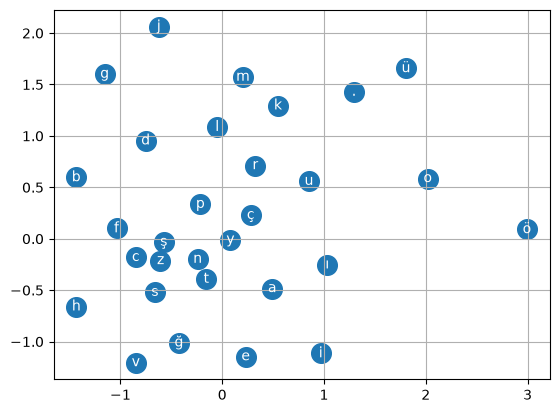

In [312]:
plt.Figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va = 'center', color = 'white')
plt.grid('minor')

In [ ]:
# y, n, t, ş, z, s, f, ç, t gibi harflerin bir cluster oluşturduğunu görüyoruz.

In [16]:
# embedding boyutunu artırma görevi

vocab_size = len(stoi)   # 30
block_size = 3
n_embd = 10                # embedding boyutu
n_hidden = 300             # gizli katman nöron sayısı

g = torch.Generator().manual_seed(42)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

18630

In [17]:
lossi = []
stepi = []

In [35]:
for i in range(30000): 
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    #forward pass

    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    


    # backward pass

    for p in parameters:
        p.grad = None
    loss.backward()

    #update
     
    for p in parameters:
        p.data += -0.1 * p.grad

    #track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

        
print(loss.item()) 

1.9336845874786377


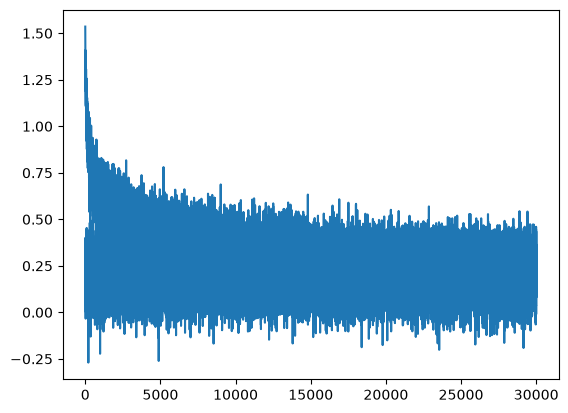

In [36]:
plt.plot(stepi, lossi)

In [37]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(1.6219, grad_fn=<NllLossBackward0>)

In [38]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(1.6443, grad_fn=<NllLossBackward0>)

In [40]:
emb = C[Xte]
h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(1.6361, grad_fn=<NllLossBackward0>)

In [ ]:
# embedding boyutu 10 gizli katman 200 lr:0.1 ve loss dev üzerinde: 1.787
# embedding boyutu 10 gizli katma 300 lr: 0.1 ve loss dev üzerinde: 1.8621 bir sonraki çalışmada 1.70 bir sonrakinde 1.69

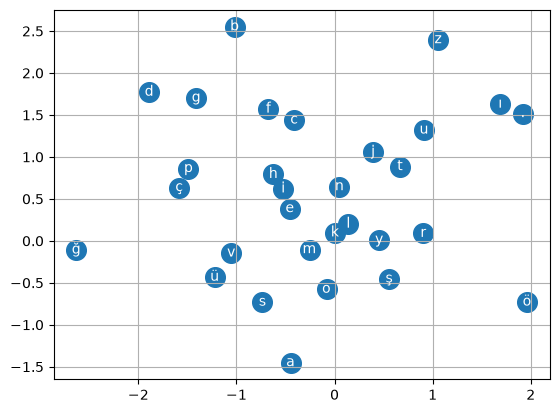

In [30]:
plt.Figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va = 'center', color = 'white')
plt.grid('minor')

In [39]:
g = torch.Generator().manual_seed(42)
for _ in range(20):
    out = []
    context = [0] * 3
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2 
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator = g ).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

baran.
yaman.
uğur.
gündüzperihatih.
berterdemin.
bulut.
nadirulviyir.
gürk.
mesut.
mertuğba.
begümafak.
boray.
kadertan.
nadir.
bertsadık.
kadir.
kaderihan.
buseorkun.
kübal.
özgumfer.


In [ ]:
''' 
bak.
yaızs.
ba.
slmik.
s.
a.
tangduzgura.
cıkahz.
çk.
daçandevapı.
ta.
an.
mbeyulangü.
bikunybesak.
tgan.
kay.
andophaya.
k.
hay.
balarüşegin.
yırıpan.
narerabungi.
ksık.
alalukan.
ayzörki.
...
musu.
tvça.
kçuözulbul.
a.
'''